STEP 3: SRTM (reference) - ASTER, Hugonnet et al. (2021) methodology

Loading reference DEM and masks...
  Reference grid: (3715, 3006), 30.0 m, EPSG:32643
  Glacier px: 104,422   Stable px: 825

Found 65 ASTER .tif files under D:\thesis\Malangutti\AST14DEM

--- AST14DEM_00410132000060644_20250130011929  (2000-10-13) ---
  Raw RMSE (stable terrain): 25.67 m
  Final stable-terrain RMSE after 'nuth_kaab': 22.62 m  (NMAD=19.16 m)  (ABOVE Hugonnet 20 m RMSE threshold)
  Applying per-elevation-band NMAD filter + hypsometric gap-fill:
    Hypsometric mean dh (full glacier area, gap-filled): +23.526 m
  FINAL glacier dh 2000-02-11 -> 2000-10-13 (gap-filled to full area)
    mean=+26.232 m  median=+19.287 m  NMAD=30.085 m  std=33.579 m  n=104,422
    Hypsometric-weighted mean dh: +23.526 m
  Saved: D:\thesis\Python_Elevation_Change\Step3_ASTER_Hugonnet\dh_20000211_20001013.tif

--- AST14DEM_00409302001055833_20250213084528  (2001-09-30) ---
  Raw RMSE (stable terrain): 27.32 m
  Final stable-t

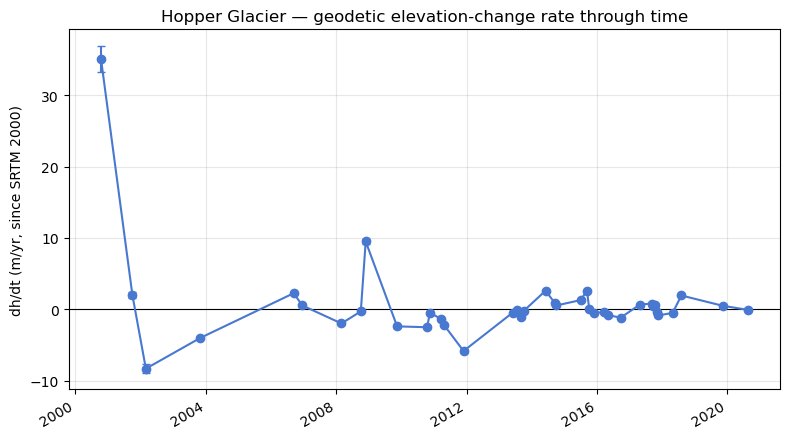

In [ ]:
"""
STEP 3 — SRTM (final, from Step 2) minus ASTER DEMs (2000-2023), Hugonnet-style
=================================================================================
Verified against the actual Hugonnet et al. (2021) Nature paper text
(Methods: "Elevation time series" and "Integration of elevation into
volume changes"). Two things were corrected here versus the first draft
of this script / versus your original notebooks:

  * ACCEPTANCE GATE IS RMSE, NOT NMAD. The paper: "we excluded all DEMs
    for which the root-mean-square error of the elevation difference
    with TanDEM-X on ice-free terrain was larger than 20 m." Some of
    your notebook comments had this backwards (claiming NMAD is the
    gate and RMSE is "inflated / not the acceptance metric") - that is
    not what the paper says. RMSE (on stable terrain, after
    co-registration) is now the accept/reject test; NMAD is still
    reported alongside it for reference.

  * OUTLIER FILTER ON THE GLACIER IS A PER-ELEVATION-BAND 5xNMAD FILTER
    + HYPSOMETRIC GAP-FILL, not an iterative whole-glacier [5,4,3]xNMAD
    sweep. The paper: "Pixels with a 20-year elevation change larger
    than five times the NMAD from the median elevation change of the
    elevation bin were removed. If no valid elevation estimate existed
    within a given bin, the elevation change was linearly interpolated
    from adjacent bins, or extrapolated from the closest bins." This
    also means AREA should be the true glacier area (all bins,
    gap-filled), not just the count of pixels that survived filtering.

Pipeline per ASTER scene:
  1. Co-register ASTER onto the reference DEM using Nuth & Kaab (2011),
     fit on stable terrain only (falls back to planar de-tilt if NK does
     not converge or leaves the error worse).
  2. Compute dh = ASTER_corrected - SRTM_reference on the glacier.
  3. Physical-plausibility clip (DH_PHYS_MIN/MAX).
  4. Per-elevation-band 5xNMAD filter + hypsometric gap-fill (paper's
     actual volume-integration method).
  5. Rolstad et al. (2009) uncertainty propagation (a documented
     SIMPLIFICATION of the paper's full multi-range variogram approach,
     which needs a dense multi-decadal time series this workflow
     doesn't have - see dem_utils.rolstad_uncertainty docstring), plus
     density-conversion uncertainty (850 +/- 60 kg/m3, per the paper).
  6. Accept/flag the scene against the Hugonnet RMSE<20 m criterion.
  7. Save a co-registered+filtered dh GeoTIFF, a diagnostic figure, and
     append one row to a master results CSV covering ALL scenes 2000-2023.

Filename convention expected for ASTER granules: put the acquisition date
in ACQ_DATES below (safer than trying to auto-parse ASTER's own filename,
which does not encode a clean date). One row per file.
"""

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dem_utils import (
    load_dem, reproject_match, rasterize_mask, compute_slope_aspect,
    nuth_kaab_coregister, planar_detilt, hypsometric_filter_and_fill,
    rolstad_uncertainty, density_conversion_uncertainty,
    print_stats, nmad, robust_rmse, save_raster,
)

# ============================== CONFIG ======================================
SRTM_REF_PATH = r"D:\thesis\Malangutti\Malangutti\Step2_SRTM_TanDEMX\SRTM_final_corrected.tif"
SRTM_DATE     = "2000-02-11"

GLACIER_SHP   = r"D:\thesis\Malangutti\Glacier_RGI_7\Malangutti_Glacier.shp"
STABLE_SHP    = r"D:\thesis\Malangutti\Stable Terrain\Stable_terrain.shp"

ASTER_DIR     = r"D:\thesis\Malangutti\AST14DEM"     # searched recursively
ASTER_GLOB    = "**/*.tif"

# filename (without extension) -> acquisition date "YYYY-MM-DD"
# fill this in for every ASTER granule you have
ACQ_DATES = {
    "AST14DEM_00410132000060644_20250130011929": "2000-10-13",
    "AST14DEM_00409302001055833_20250213084528": "2001-09-30",
    "AST14DEM_00402282002060026_20250219141359": "2002-02-28",
    "AST14DEM_00410292003055845_20250317124328": "2003-10-29",
    "AST14DEM_00410152004055752_20250401223447": "2004-10-15",
    "AST14DEM_00411052005054545_20250522132940": "2005-11-05",
    "AST14DEM_00409122006055221_20250530173235": "2006-09-12",
    "AST14DEM_00410302006055204_20250531225232": "2006-10-30",
    "AST14DEM_00412172006055221_20250605154452": "2006-12-17",
    "AST14DEM_00405262007055235_20251209192738": "2007-05-26",
    "AST14DEM_00402292008055846_20250620155216": "2008-02-29",
    "AST14DEM_00404012008055844_20250621022726": "2008-04-01",
    "AST14DEM_00410032008055305_20250623193449": "2008-10-03",
    "AST14DEM_00411272008055913_20250624152837": "2008-11-27",
    "AST14DEM_00411142009055859_20250701013539": "2009-11-14",
    "AST14DEM_00410022010054627_20250706125004": "2010-10-02",
    "AST14DEM_00410162010055825_20250706172707": "2010-10-16",
    "AST14DEM_00411172010055831_20250707031517": "2010-11-17",
    "AST14DEM_00403252011055832_20250708212514": "2011-03-25",
    "AST14DEM_00404262011055839_20250709143238": "2011-04-26",
    "AST14DEM_00410122011055216_20250712124449": "2011-10-12",
    "AST14DEM_00411292011055214_20250713040531": "2011-11-29",
    "AST14DEM_00410302012055221_20250719224806": "2012-10-30",
    "AST14DEM_00406022013055901_20250724063352": "2013-06-02",
    "AST14DEM_00407202013055846_20250724215520": "2013-07-20",
    "AST14DEM_00409062013055904_20250725162011": "2013-09-06",
    "AST14DEM_00410012013055248_20250726014713": "2013-10-01",
    "AST14DEM_00411182013055240_20250726133445": "2013-11-18",
    "AST14DEM_00402072020055303_20250907030750": "2020-02-07",
    "AST14DEM_00403222016055851_20250811122457": "2016-03-22",
    "AST14DEM_00404262017055854_20250821011116": "2017-04-26",
    "AST14DEM_00404292018055952_20250826214127": "2018-04-29",
    "AST14DEM_00405092016055924_20250812020416": "2016-05-09",
    "AST14DEM_00406052014055929_20250728091121": "2014-06-05",
    "AST14DEM_00407032015055357_20250807104843": "2015-07-03",
    "AST14DEM_00408052018054805_20250828173128": "2018-08-05",
    "AST14DEM_00408172020055246_20250910200307": "2020-08-17",
    "AST14DEM_00409102017055318_20250823140130": "2017-09-10",
    "AST14DEM_00409122015055929_20250808200445": "2015-09-12",
    "AST14DEM_00409182014055312_20250802012012": "2014-09-18",
    "AST14DEM_00409232016055302_20250816033036": "2016-09-23",
    "AST14DEM_00409262017055315_20250823200202": "2017-09-26",
    "AST14DEM_00410042014055315_20250802080520": "2014-10-04",
    "AST14DEM_00410072015055304_20250809045548": "2015-10-07",
    "AST14DEM_00410122017055307_20250824004924": "2017-10-12",
    "AST14DEM_00411042017055904_20250824060807": "2017-11-04",
    "AST14DEM_00411102019055832_20250905231939": "2019-11-10",
    "AST14DEM_00411202017055903_20250824090042": "2017-11-20",
    "AST14DEM_00412012015055921_20250809165646": "2015-12-01",
    
}

OUT_DIR       = r"D:\thesis\Malangutti\Step3_ASTER_Hugonnet"
PROJ_CRS      = "EPSG:32643"
TARGET_RES    = 30

MAX_DH_COREG  = 200.0
MIN_SLOPE     = 3.0
# Verified against the paper's own wording: the accept/reject gate is RMSE
# on ice-free (stable) terrain after co-registration, not NMAD.
MAX_RMSE_ACCEPT = 20.0
DH_PHYS_MIN, DH_PHYS_MAX = -150.0, 150.0   # physically plausible dh bounds (m)
BAND_WIDTH_M  = 100.0      # elevation-band width for hypsometric filter/gap-fill
BAND_NMAD_SIGMA = 5.0      # paper: "larger than five times the NMAD ... removed"
ICE_DENSITY   = 850.0      # kg/m3
ICE_DENSITY_UNCERT = 60.0  # kg/m3 (paper: "density conversion factor of 850 +/- 60")
L_CORR_M      = 500.0      # Rolstad decorrelation length (m) - see NOTE in dem_utils
AREA_UNCERT_FRAC = 0.0     # set e.g. 0.02 for a 2% outline-uncertainty term if known
MIN_SNR       = 2.0
# =============================================================================

os.makedirs(OUT_DIR, exist_ok=True)


def process_one_scene(aster_path, aster_date, tdx_like_ref, glacier_mask,
                       stable_mask, slope, aspect, elevation, res_m):
    """Run the full co-registration + dh + uncertainty pipeline for one ASTER scene."""
    aster = reproject_match(load_dem(aster_path), tdx_like_ref)
    aster_arr = aster.values.astype(float)
    ref_arr = tdx_like_ref.values.astype(float)

    dh_raw = aster_arr - ref_arr
    m_raw = stable_mask & np.isfinite(dh_raw) & (np.abs(dh_raw) < MAX_DH_COREG)
    if m_raw.sum() < 100:
        print("  Not enough valid stable-terrain overlap — skipping scene.")
        return None

    rmse_raw = robust_rmse(dh_raw[m_raw])
    print(f"  Raw RMSE (stable terrain): {rmse_raw:.2f} m")

    # --- Try Nuth-Kaab first ---
    fix_used = "nuth_kaab"
    try:
        aster_fixed, shift, diag = nuth_kaab_coregister(
            aster_arr, ref_arr, slope, aspect, res_m, stable_mask,
            max_dh=MAX_DH_COREG, min_slope_deg=MIN_SLOPE, verbose=False,
        )
        dh_chk = aster_fixed - ref_arr
        m_chk = stable_mask & np.isfinite(dh_chk) & (np.abs(dh_chk) < MAX_DH_COREG)
        rmse_fix = robust_rmse(dh_chk[m_chk])
        nmad_fix = diag["nmad_post"]
    except Exception as e:
        print(f"  Nuth-Kaab failed ({e}); falling back to planar de-tilt.")
        aster_fixed, coeffs = planar_detilt(
            aster_arr, ref_arr, tdx_like_ref.x.values, tdx_like_ref.y.values,
            stable_mask, max_dh=MAX_DH_COREG,
        )
        dh_chk = aster_fixed - ref_arr
        m_chk = stable_mask & np.isfinite(dh_chk) & (np.abs(dh_chk) < MAX_DH_COREG)
        rmse_fix = robust_rmse(dh_chk[m_chk])
        nmad_fix = nmad(dh_chk[m_chk])
        fix_used = "planar_detilt"

    # If NK didn't actually help (paper's own gate is RMSE), try planar and
    # keep whichever gives the lower stable-terrain RMSE.
    if rmse_fix > rmse_raw or not np.isfinite(rmse_fix):
        try:
            aster_plane, coeffs = planar_detilt(
                aster_arr, ref_arr, tdx_like_ref.x.values, tdx_like_ref.y.values,
                stable_mask, max_dh=MAX_DH_COREG,
            )
            dh_chk = aster_plane - ref_arr
            m_chk = stable_mask & np.isfinite(dh_chk) & (np.abs(dh_chk) < MAX_DH_COREG)
            rmse_plane = robust_rmse(dh_chk[m_chk])
            if rmse_plane < rmse_fix:
                aster_fixed = aster_plane
                rmse_fix = rmse_plane
                nmad_fix = nmad(dh_chk[m_chk])
                fix_used = "planar_detilt"
        except Exception:
            pass

    accepted = rmse_fix <= MAX_RMSE_ACCEPT
    print(f"  Final stable-terrain RMSE after '{fix_used}': {rmse_fix:.2f} m  "
          f"(NMAD={nmad_fix:.2f} m)  "
          f"({'OK, RMSE<=20 m' if accepted else 'ABOVE Hugonnet 20 m RMSE threshold'})")

    # --- dh on glacier ---
    dh = aster_fixed - ref_arr
    dh_gl = np.where(glacier_mask, dh, np.nan)
    dh_gl[np.isfinite(dh_gl) & ((dh_gl < DH_PHYS_MIN) | (dh_gl > DH_PHYS_MAX))] = np.nan

    # Hugonnet et al. (2021) actual volume-integration filter: per
    # elevation-band 5xNMAD rejection + hypsometric gap-fill, rather than
    # an iterative whole-glacier sigma sweep.
    print("  Applying per-elevation-band NMAD filter + hypsometric gap-fill:")
    dh_gl_filled, band_table, mean_dh_hypso = hypsometric_filter_and_fill(
        dh_gl, elevation, glacier_mask,
        bin_width=BAND_WIDTH_M, nmad_sigma=BAND_NMAD_SIGMA,
    )

    final_v = dh_gl_filled[glacier_mask & np.isfinite(dh_gl_filled)]
    n_glacier_total = int(glacier_mask.sum())  # TRUE glacier area, all bins
    if final_v.size == 0:
        print("  No valid glacier pixels after filtering — skipping scene.")
        return None

    area_km2 = n_glacier_total * res_m ** 2 / 1e6
    stats = print_stats(final_v, f"FINAL glacier dh {SRTM_DATE} -> {aster_date} "
                                  f"(gap-filled to full area)")
    # Report the hypsometric (area-weighted-by-band) mean as the headline
    # number, matching the paper's local hypsometric method more closely
    # than a flat pixel mean.
    print(f"    Hypsometric-weighted mean dh: {mean_dh_hypso:+.3f} m")

    years = (pd.to_datetime(aster_date) - pd.to_datetime(SRTM_DATE)).days / 365.25
    dh_rate = mean_dh_hypso / years
    sigma_area_m2 = AREA_UNCERT_FRAC * area_km2 * 1e6

    sigma_mean = rolstad_uncertainty(stats["nmad"], area_km2 * 1e6, L_CORR_M)
    sigma_dh_total = np.sqrt(sigma_mean ** 2 + (nmad_fix / np.sqrt(max(final_v.size, 1))) ** 2)
    sigma_rate = sigma_dh_total / years

    mb = density_conversion_uncertainty(
        dh_rate, sigma_rate, area_km2 * 1e6, sigma_area_m2,
        density=ICE_DENSITY, sigma_density=ICE_DENSITY_UNCERT,
    )
    gmb_rate, sigma_gmb = mb["mwe_rate"], mb["sigma_mwe_rate"]
    snr_mean = abs(dh_rate) / sigma_rate if sigma_rate > 0 else np.nan

    # --- save outputs ---
    scene_tag = aster_date.replace("-", "")
    dh_out_path = os.path.join(OUT_DIR, f"dh_{SRTM_DATE.replace('-','')}_{scene_tag}.tif")
    save_raster(np.where(glacier_mask, dh_gl_filled, np.nan), tdx_like_ref, PROJ_CRS, dh_out_path)

    fig, ax = plt.subplots(figsize=(6, 6))
    vmax = min(20, np.nanpercentile(np.abs(final_v), 98))
    im = ax.imshow(np.where(glacier_mask, dh_gl_filled, np.nan),
                    cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"dh {SRTM_DATE} -> {aster_date}\n"
                 f"hypsometric mean={mean_dh_hypso:+.2f} m  NMAD={stats['nmad']:.2f} m")
    plt.colorbar(im, shrink=0.7, label="dh (m)")
    fig.savefig(os.path.join(OUT_DIR, f"dh_{scene_tag}.png"), dpi=150)
    plt.close(fig)

    return dict(
        Glacier="Hopper", Date_start=SRTM_DATE, Date_end=aster_date,
        Years=round(years, 4), Area_km2=round(area_km2, 4),
        N_glacier_pixels=n_glacier_total,
        Mean_dh_m=round(stats["mean"], 4),
        Median_dh_m=round(stats["median"], 4),
        Hypsometric_mean_dh_m=round(mean_dh_hypso, 4),
        NMAD_m=round(stats["nmad"], 4), Std_dh_m=round(stats["std"], 4),
        Rate_m_yr=round(dh_rate, 5), Rate_err_m_yr=round(sigma_rate, 5),
        GMB_mwe_yr=round(gmb_rate, 5), GMB_err_mwe_yr=round(sigma_gmb, 5),
        SNR_mean=round(snr_mean, 2) if np.isfinite(snr_mean) else None,
        Coreg_method=fix_used,
        Coreg_RMSE_stable_m=round(rmse_fix, 4),
        Coreg_NMAD_stable_m=round(nmad_fix, 4),
        Accepted_RMSE_lt_20m=bool(accepted),
    )


def main():
    print("=" * 70)
    print("STEP 3: SRTM (reference) - ASTER, Hugonnet et al. (2021) methodology")
    print("=" * 70)

    print("\nLoading reference DEM and masks...")
    ref = load_dem(SRTM_REF_PATH).rio.reproject(PROJ_CRS, resolution=TARGET_RES)
    glacier_mask = rasterize_mask(GLACIER_SHP, ref)
    stable_mask = rasterize_mask(STABLE_SHP, ref)
    res_x, _ = ref.rio.resolution()
    res_m = abs(res_x)
    slope, aspect = compute_slope_aspect(ref.values.astype(float), res_m)
    print(f"  Reference grid: {ref.shape}, {res_m:.1f} m, {PROJ_CRS}")
    print(f"  Glacier px: {glacier_mask.sum():,}   Stable px: {stable_mask.sum():,}")

    aster_files = sorted(glob.glob(os.path.join(ASTER_DIR, ASTER_GLOB), recursive=True))
    print(f"\nFound {len(aster_files)} ASTER .tif files under {ASTER_DIR}")

    results = []
    for path in aster_files:
        key = os.path.splitext(os.path.basename(path))[0]
        aster_date = ACQ_DATES.get(key)
        if aster_date is None:
            print(f"\nSkipping (no acquisition date registered in ACQ_DATES): {key}")
            continue
        print(f"\n--- {key}  ({aster_date}) ---")
        try:
            row = process_one_scene(
                path, aster_date, ref, glacier_mask, stable_mask, slope, aspect,
                ref.values.astype(float), res_m,
            )
            if row:
                results.append(row)
        except Exception as e:
            print(f"  FAILED: {e}")

    if results:
        df = pd.DataFrame(results).sort_values("Date_end")
        csv_path = os.path.join(OUT_DIR, "Hopper_SRTM_ASTER_Hugonnet_results.csv")
        df.to_csv(csv_path, index=False)
        print(f"\nSaved master results table: {csv_path}")
        print(df[["Date_end", "Area_km2", "Median_dh_m", "NMAD_m",
                   "Rate_m_yr", "GMB_mwe_yr", "Accepted_RMSE_lt_20m"]].to_string(index=False))

        # quick dh/dt time series plot
        fig, ax = plt.subplots(figsize=(8, 4.5))
        dates = pd.to_datetime(df["Date_end"])
        ax.errorbar(dates, df["Rate_m_yr"], yerr=df["Rate_err_m_yr"],
                    fmt="o-", capsize=3, color="#4878d0")
        ax.axhline(0, color="k", lw=0.8)
        ax.set_ylabel("dh/dt (m/yr, since SRTM 2000)")
        ax.set_title("Hopper Glacier — geodetic elevation-change rate through time")
        ax.grid(alpha=0.3)
        fig.autofmt_xdate()
        fig.tight_layout()
        fig.savefig(os.path.join(OUT_DIR, "dhdt_timeseries.png"), dpi=150)
        plt.show()
    else:
        print("\nNo scenes were successfully processed.")


if __name__ == "__main__":
    main()
